# 02 - Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_style('whitegrid')
df = pd.read_csv('../data/cleaned/cleaned_data.csv')
df.shape

(20640, 10)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Target distribution

In [4]:
TARGET = 'median_house_value'

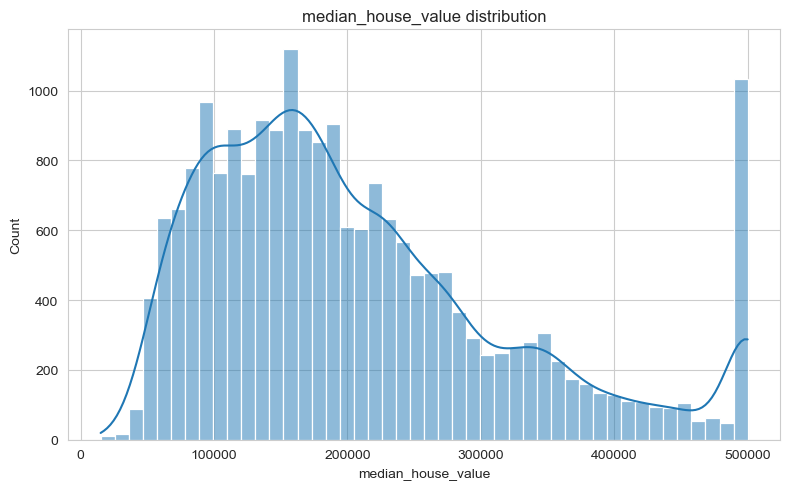

Skew: 0.9777632739098341


In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], kde=True)
plt.title(f'{TARGET} distribution')
plt.tight_layout()
plt.show()

print('Skew:',df[TARGET].skew())

### Observation: 
- The median_house_value distribution is right-skewed, with most houses valued between 100,000 and 250,000.
- There is a spike at 500,000 indicates that the target variable is capped at this maximum value.
- Traget varable is not normaly distributed

## Numeric feature distributions

In [6]:
def hist_box_plot(col,df):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        
    print(f"\n {col} | Skew: {df[col].skew():.2f} | Outliers: {outlier_count} ({outlier_count/len(df)*100:.1f}%)")
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
    sns.histplot(df[col], kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(df[col].mean(), color='red', linestyle='--', label=(f"Mean{df[col].mean():.2f}"))
    axes[0].axvline(df[col].median(), color='green', linestyle='--', label=(f"Median{df[col].median():.2f}"))
    axes[0].set_title(f'{col} - Distribution')
    axes[0].legend()
        
    sns.boxplot(x=df[col], ax=axes[1], color='skyblue')
    axes[1].set_title(f'{col} - Boxplot')
        
    plt.tight_layout()
    plt.show()

### Geographic view using "longitude" and "latitude"

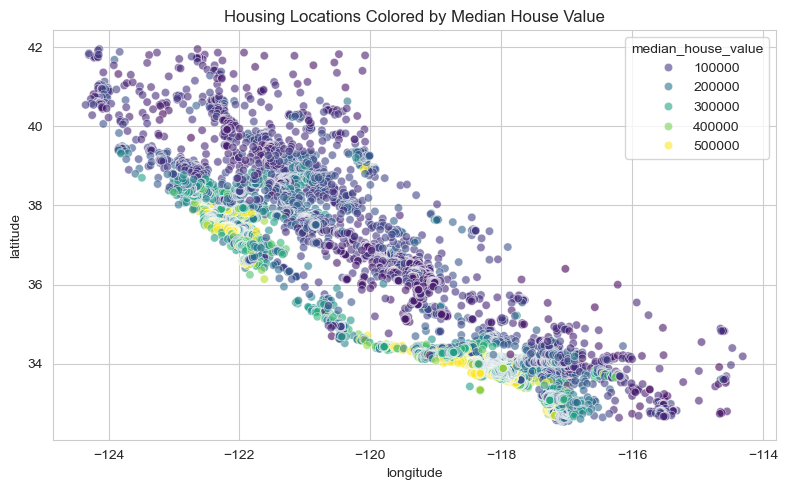

In [7]:
plt.figure(figsize=(8,5))
plt.tight_layout()
sns.scatterplot(data=df, x='longitude', y='latitude', hue=TARGET, palette="viridis", alpha=0.6)
plt.title("Housing Locations Colored by Median House Value")
plt.tight_layout()
plt.show()

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != TARGET]
numeric_cols

['longitude',
 'latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']


 housing_median_age | Skew: 0.06 | Outliers: 0 (0.0%)


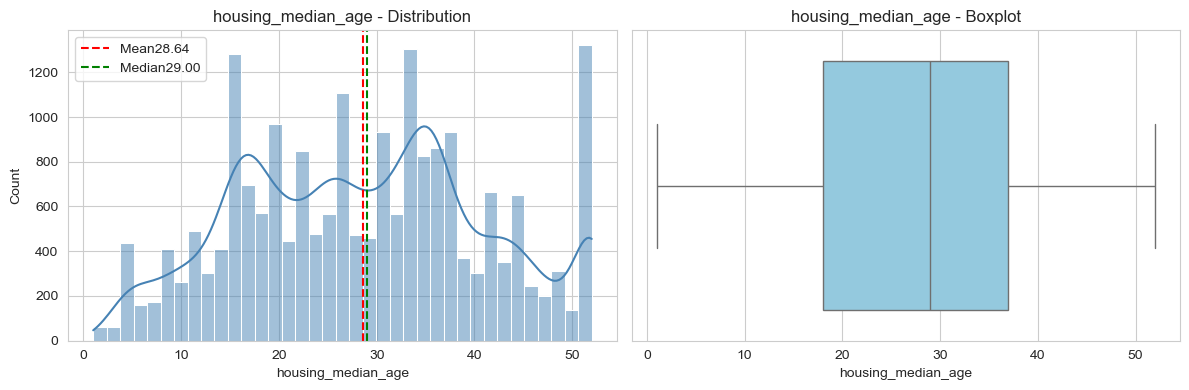

In [9]:
hist_box_plot('housing_median_age',df)

### Observation
- The histogram is irregular and contains multiple peaks rather than a single bell-shaped curve.
- There is a noticeable spike at 52 years, indicating that the variable is capped at this maximum value in the dataset. 
- The mean (28.64) and median (29.00) are very close, suggesting little overall skewness.


 total_rooms | Skew: 4.15 | Outliers: 1287 (6.2%)


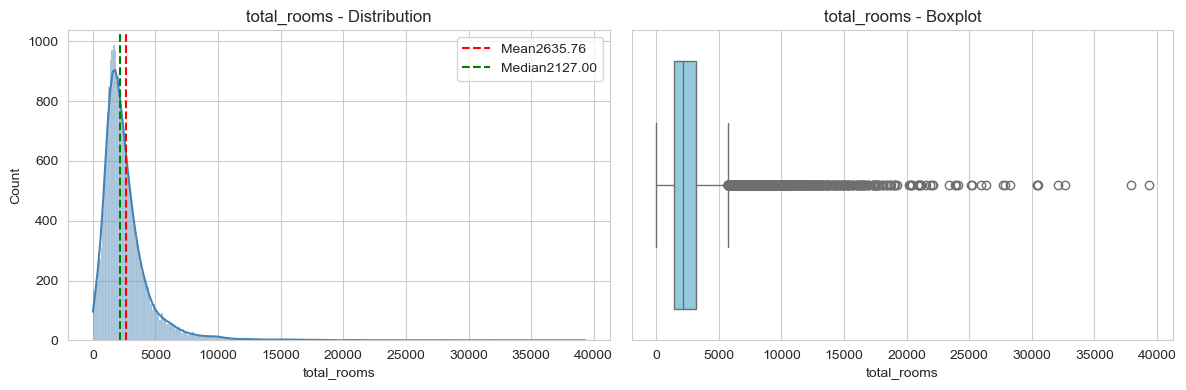

In [10]:
hist_box_plot('total_rooms',df)

### Observation
- The total_rooms feature is highly positively skewed **(skew=  4.15)** and is not normally distributed.
- Most observations are concentrated at lower values, while a long right tail extends toward larger values.
- The mean (2635.76) is higher than the median (2127.00), confirming the positive skewness.
- The boxplot also reveals high-value outliers.


 total_bedrooms | Skew: 3.46 | Outliers: 1271 (6.2%)


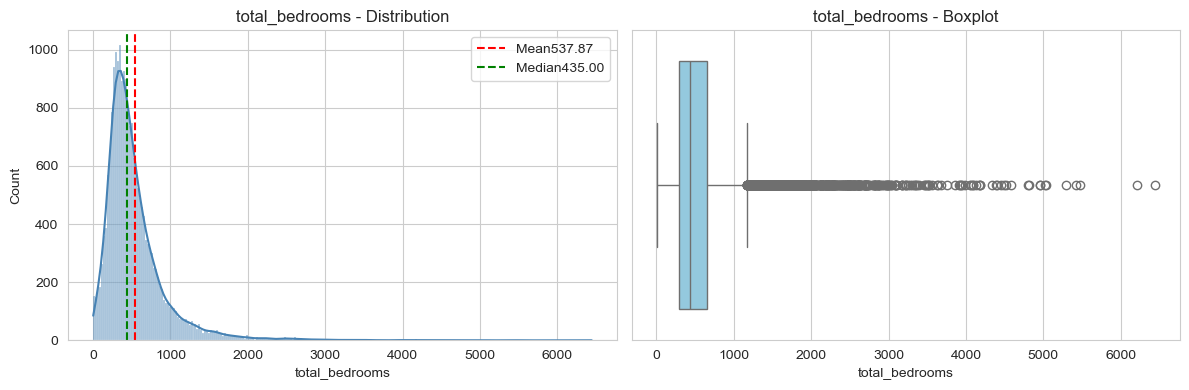

In [11]:
hist_box_plot('total_bedrooms',df)

### Observation: 
- The total_bedrooms feature is highly right-skewed **(Skew: 3.46)**
- Most observations are concentrated at lower values, while a long right tail extends toward larger values.
- The mean (537.87) is greater than the median (435.00), confirming the positive skewness.
- The boxplot also indicates the presence of high-value outliers.


 population | Skew: 4.94 | Outliers: 1196 (5.8%)


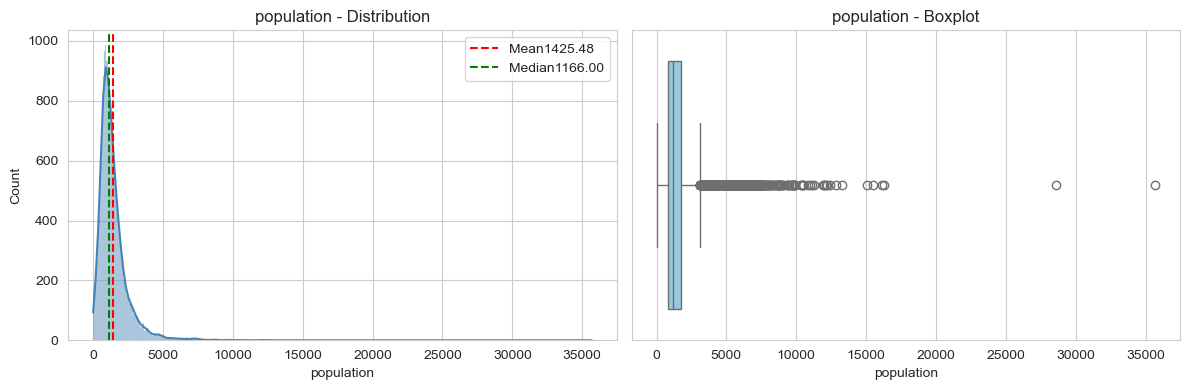

In [12]:
hist_box_plot('population',df)

### Observation: 
- The population feature is highly positively skewed (Skew: 4.94) and is not normally distributed.
- Most observations are concentrated at lower population values, while a long right tail extends toward much larger populations.
- The mean (1425.48) is greater than the median (1166.00), indicating positive skewness.
- The boxplot also shows high-value outliers, including a few extreme observations.


 households | Skew: 3.41 | Outliers: 1220 (5.9%)


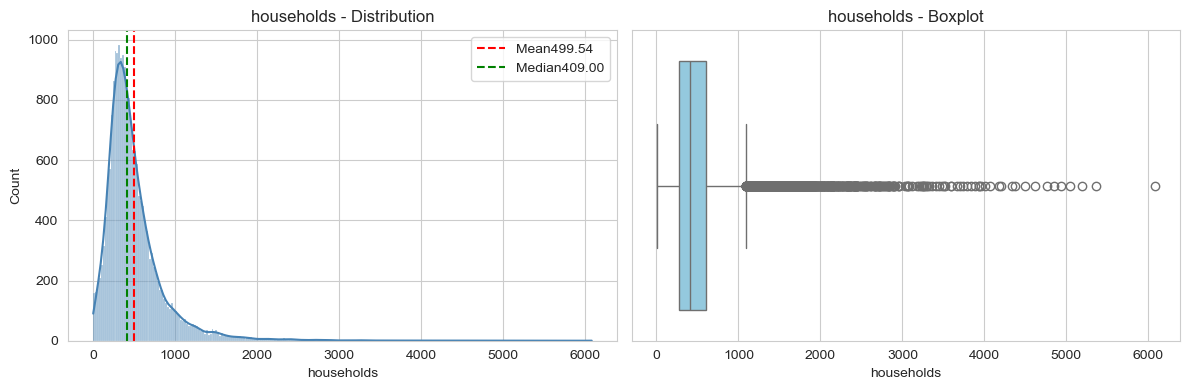

In [13]:
hist_box_plot('households',df)

### Observation: 
- The households feature is highly positively skewed (Skew: 3.41)
- Most observations are concentrated at lower household counts, while a long right tail extends toward higher values.
- The mean (499.54) is greater than the median (409.00), indicating positive skewness.
- The boxplot also reveals high-value outliers.


 median_income | Skew: 1.65 | Outliers: 681 (3.3%)


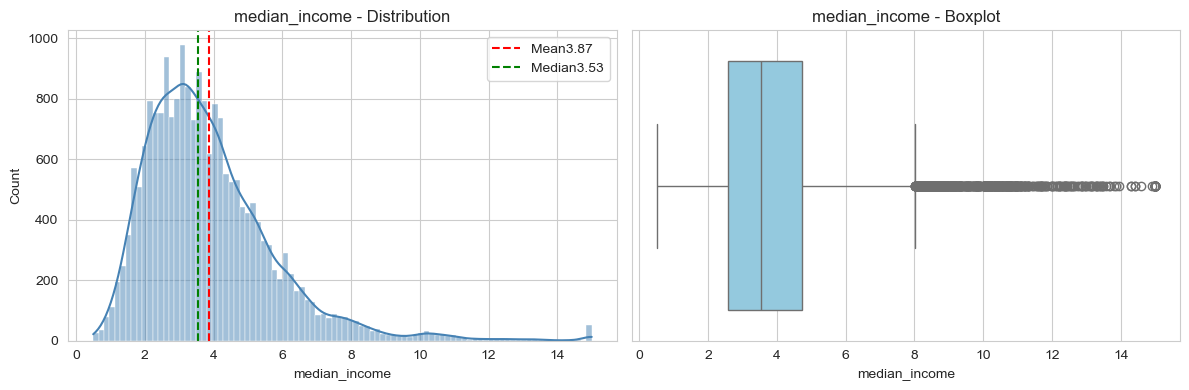

In [14]:
hist_box_plot('median_income',df)

### Observation: 
- The median_income feature is moderately positively skewed (Skew: 1.65)
- Most observations are concentrated between 2 and 6, while a long right tail extends toward higher income values.
- The mean (3.87) is slightly greater than the median (3.53), indicating positive skewness.
- The boxplot also reveals the presence of several high-income outliers.
- median_income is only moderately right-skewed, so its distribution is closer to symmetric

## Correlation with target

In [15]:
target_corr = df.select_dtypes(include='number').corr()[TARGET].sort_values(ascending=False)
target_corr

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

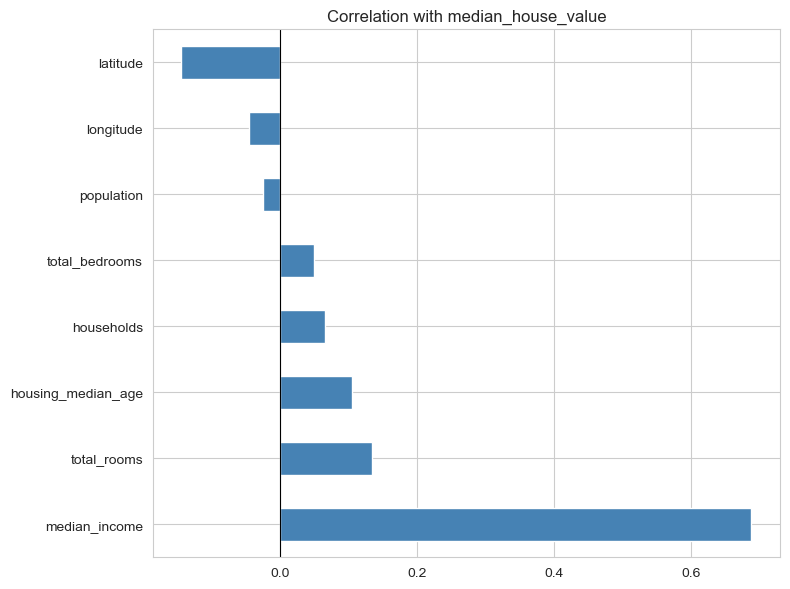

In [16]:
plt.figure(figsize=(8, 6))
target_corr.drop(TARGET).plot(kind='barh', color='steelblue')
plt.title(f'Correlation with {TARGET}')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

### Observation: 
- median_income has the strongest positive correlation with median_house_value (≈0.69)
- Indicating it is the most important numerical feature for prediction.
- The remaining features shows weak positive or negative correlations.

## Correlation between features (multicollinearity check)

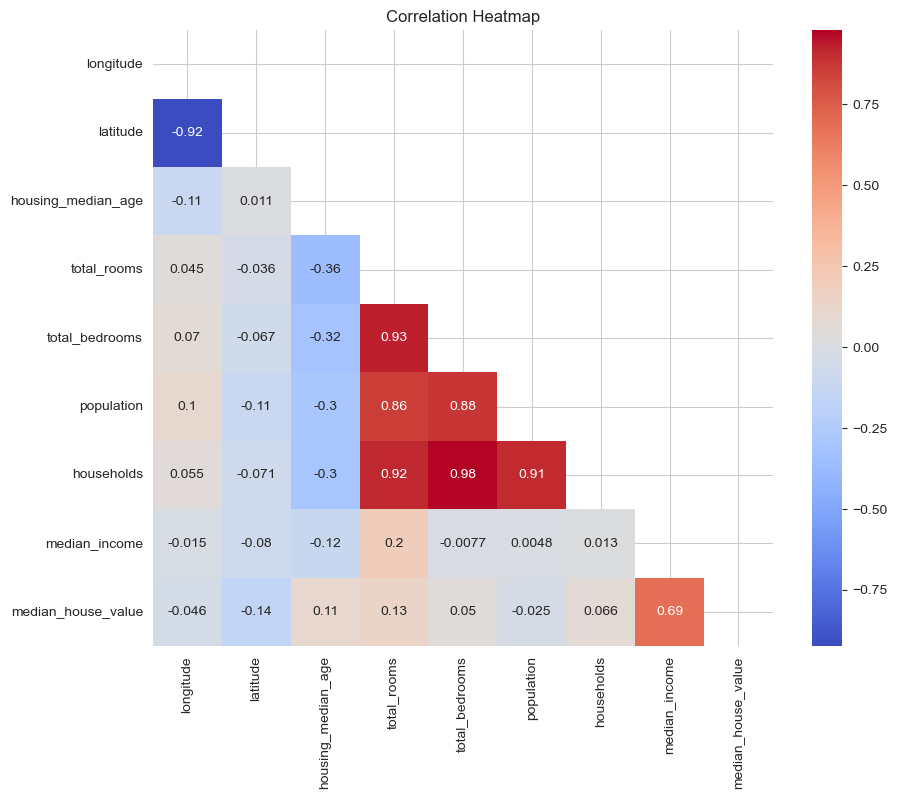

In [17]:
corr_matrix = df.select_dtypes(include=np.number).corr()
mask= np.triu(np.ones_like(corr_matrix,dtype=bool))
plt.figure(figsize=(10,8))
plt.tight_layout()
sns.heatmap(corr_matrix,fmt='.2g',annot=True,mask=mask,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Observation: 
- The heatmap shows that median_income has the strongest positive linear relationship with median_house_value (0.69).
- The features total_rooms, total_bedrooms, population, and households are highly correlated with one another, indicating potential multicollinearity.
- Additionally, longitude and latitude shows strong negative correlation (-0.92).
- Most remaining feature pairs have weak correlations.

## Categorical feature vs target

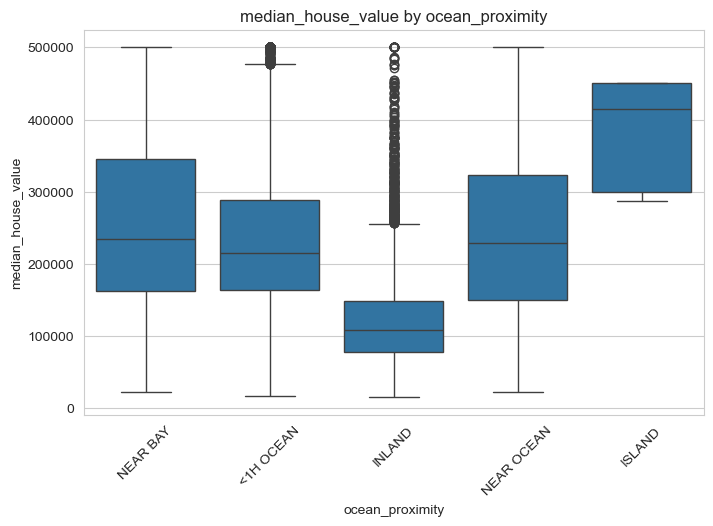

In [18]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=c, y=TARGET, data=df)
    plt.title(f'{TARGET} by {c}')
    plt.xticks(rotation=45)
    plt.show()

### Observation: 
- House prices vary noticeably across the ocean_proximity categories.
- The ISLAND category has the highest median house values, although it contains only five observations.
- The INLAND category has the lowest median house values.
- Properties located near the coast (NEAR BAY, NEAR OCEAN, and <1H OCEAN) generally have higher median house values.
- This suggests that proximity to the ocean is associated with higher housing prices.

## Summary observations
- The dataset consists of 20,640 records with one categorical feature (ocean_proximity) and a total of 207 missing values in total_bedrooms.
- Most of the numerical features are right skewed with high-value outliers.
- The target variable (median_house_value) is right skewed with a cap at $500,000.
- median_income has the highest positive correlation (0.69) with the target and thus is the most influential numerical feature.
- total_rooms, total_bedrooms, population and households are highly correlated which means multicollinearity.
- Homes near the ocean have higher median house values than those located inland.